# Data Analysis 

## Dataset
[Super Market Dataset](https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales/data)

## Details
**Name:** Arden Diago
**Class:** MCA-A
**Reg No:** 2547112

In [8]:
# importing all the modules

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sn

In [7]:
# Reading the data

df = pd.read_csv("data/SuperMarket Analysis.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

The Mean: 5.51, Median: 5.0, Mode: 10


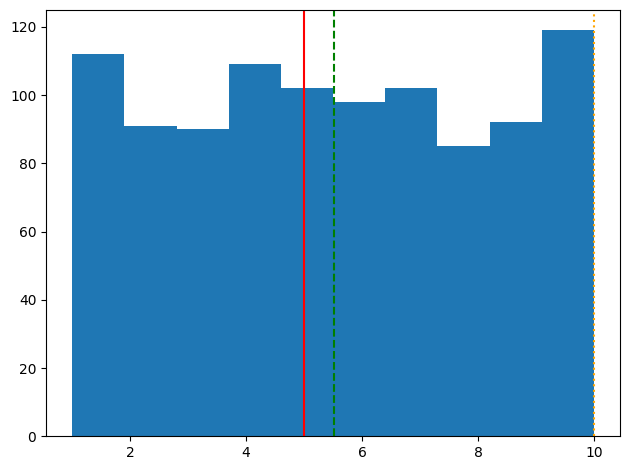

In [58]:
# Central tendency of data (Visual; Numeric)

def find_central_tendency(column_name):
    mean = df[column_name].mean()
    median = df[column_name].median()
    mode = df[column_name].mode()[0]
    print(f"The Mean: {mean}, Median: {median}, Mode: {mode}")
    
    # Diagram
    plt.hist(df[column_name],bins=10)
    
    # Central Line
    plt.axvline(mean, linestyle='--', label='Mean', color='green')
    plt.axvline(median, linestyle='-', label='Median', color='red')
    plt.axvline(mode, linestyle=':', label='Mode', color='orange')
    plt.tight_layout()
    plt.show()

find_central_tendency("Quantity")

# Outlier identification (Visual ; Numeric). Add outliers if the dataset does not have any.

In [54]:
for column in columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(f"{column}: {len(outliers)} outliers")

Quantity: 0 outliers
Unit price: 0 outliers
Tax 5%: 9 outliers
Sales: 9 outliers
cogs: 9 outliers
gross margin percentage: 0 outliers
gross income: 9 outliers
Rating: 0 outliers


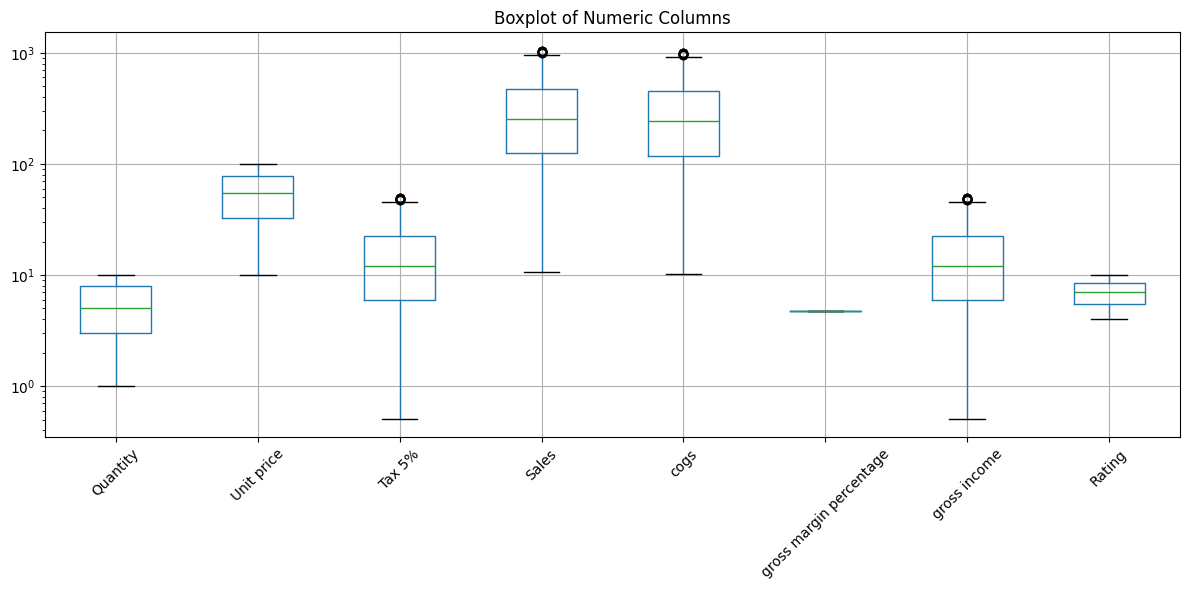

In [57]:
columns = [
    "Quantity",
    "Unit price",
    "Tax 5%",
    "Sales",
    "cogs",
    "gross margin percentage",
    "gross income",
    "Rating"
]

plt.figure(figsize=(12, 6))

df.boxplot(column=columns)
plt.yscale("log")

plt.title("Boxplot of Numeric Columns")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In this diagram there is outlires in **Tax 5%**, **Sales**, **Cogs**, and **Gross Income**. 

# Visualizing relationship between 2 numeric variables

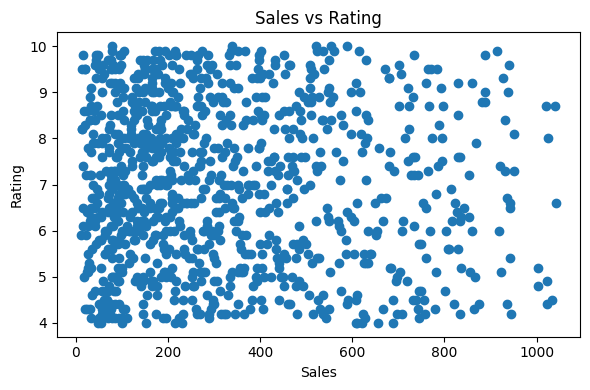

In [59]:
plt.figure(figsize=(6,4))

plt.scatter(df["Sales"], df["Rating"])

plt.xlabel("Sales")
plt.ylabel("Rating")

plt.title("Sales vs Rating")

plt.tight_layout()
plt.show()

# Visualizing relationship between numeric and nominal variable

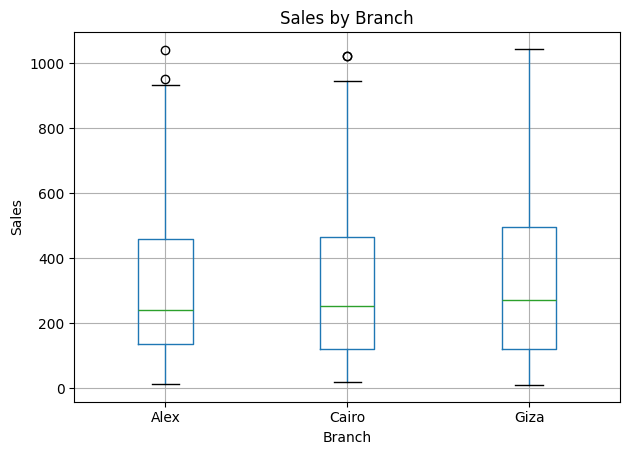

In [60]:

df.boxplot(column="Sales", by="Branch")

plt.title("Sales by Branch")
plt.suptitle("")  # removes extra automatic title

plt.xlabel("Branch")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

# Visualizing relationship between two nominal variables.

In [52]:
cross_tab = pd.crosstab(df["Gender"], df["Branch"])

print(cross_tab)

Branch  Alex  Cairo  Giza
Gender                   
Female   187    184   200
Male     153    148   128


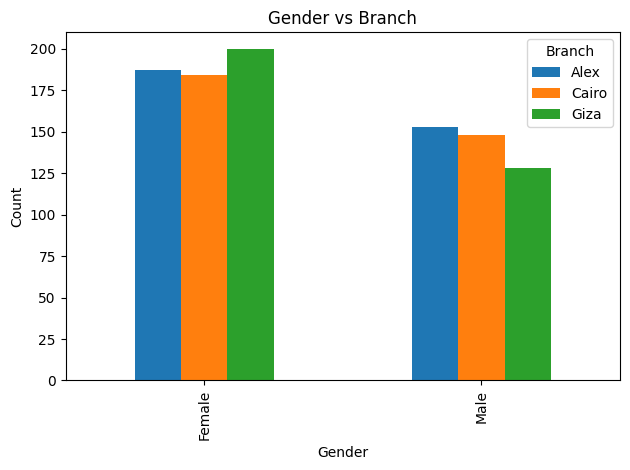

In [61]:
cross_tab.plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Count")

plt.title("Gender vs Branch")

plt.tight_layout()
plt.show()